# Imports

In [38]:
# Cell 1: Imports (cleaned & minimal)
import os
from pathlib import Path
import math

import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm

# --- Essential SciPy Imports for TPS ---
# cdist is crucial for calculating the r^2 * log(r) kernel matrix efficiently
from scipy.spatial.distance import cdist 
# linalg is needed to solve the weights for the spline
from scipy import linalg
# ndimage is used for map_coordinates (applying the warp)
from scipy.ndimage import map_coordinates

print("numpy:", np.__version__)
print("PIL:", Image.__version__)
print("cv2:", cv2.__version__)
print("SciPy loaded successfully.")

numpy: 2.2.6
PIL: 10.2.0
cv2: 4.12.0
SciPy loaded successfully.


# Path Setup

In [39]:
# === CELL 2: Path Setup ===

# Adjust these paths to match your project structure
PROJECT_ROOT = Path("..").resolve()       # notebook is inside /notebooks/
DATA_DIR = PROJECT_ROOT / "data"

DATA_RAW       = DATA_DIR / "raw" / "OriginalImages"
DATA_LANDMARKS = DATA_DIR / "landmarks" 
DATA_PROCESSED = DATA_DIR / "processed"
DATA_ALIGNED   = DATA_PROCESSED / "aligned"

# Add a specific folder for the final caricature outputs
OUTPUT_DIR     = DATA_DIR / "output_caricatures"

# Create directories if missing
DATA_RAW.mkdir(parents=True, exist_ok=True)
DATA_LANDMARKS.mkdir(parents=True, exist_ok=True)
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
DATA_ALIGNED.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:   ", PROJECT_ROOT)
print("DATA_RAW:       ", DATA_RAW)
print("DATA_LANDMARKS: ", DATA_LANDMARKS)
print("DATA_PROCESSED: ", DATA_PROCESSED)
print("DATA_ALIGNED:   ", DATA_ALIGNED)
print("OUTPUT_DIR:     ", OUTPUT_DIR)
print("\nPath setup complete ✔")

PROJECT_ROOT:    D:\Projects 2025\Caricature Generation
DATA_RAW:        D:\Projects 2025\Caricature Generation\data\raw\OriginalImages
DATA_LANDMARKS:  D:\Projects 2025\Caricature Generation\data\landmarks
DATA_PROCESSED:  D:\Projects 2025\Caricature Generation\data\processed
DATA_ALIGNED:    D:\Projects 2025\Caricature Generation\data\processed\aligned
OUTPUT_DIR:      D:\Projects 2025\Caricature Generation\data\output_caricatures

Path setup complete ✔


# Landmark Loading Helper

In [40]:
# Cell 3: Landmark loader + visualization helper
def load_landmarks(p):
    """
    Loads landmarks from a .npy file.
    Expects shape (68, 2) or (N, 2).
    """
    p = Path(p)
    if not p.exists():
        return None
    try:
        arr = np.load(str(p))
        if arr is None or arr.size == 0:
            return None
        arr = np.asarray(arr)
        
        # Ensure correct shape: (N, 2)
        if arr.ndim == 2 and arr.shape[1] == 2:
            return arr.astype(np.float32)
    except Exception as e:
        print(f"Error loading {p.name}: {e}")
        return None
    return None

def show_with_landmarks(img_path, lm_path=None, figsize=(6,6)):
    """
    Displays an image. If landmarks are found, overlays them as red dots.
    """
    if not Path(img_path).exists():
        print(f"Image not found: {img_path}")
        return
    # Load image and ensure RGB
    img = np.array(Image.open(img_path).convert('RGB'))
    
    # If landmarks path is provided, try to load and draw
    if lm_path:
        pts = load_landmarks(lm_path)
        if pts is not None:
            for (x, y) in pts:
                # Draw red circles: (255, 0, 0)
                cv2.circle(img, (int(round(x)), int(round(y))), 3, (255, 0, 0), -1)
        else:
            print(f"Warning: Landmarks not found or invalid at {lm_path}")
    # Plot final result once
    plt.figure(figsize=figsize)
    plt.imshow(img)
    plt.axis('off')
    plt.title(Path(img_path).name)
    plt.show()

print("Helper functions defined ✔")

Helper functions defined ✔


# Landmark Extraction (AFTER resize & pad)

In [41]:
# Cell 4: Landmark extraction using face_alignment (DEMO friendly)
# Install: pip install face-alignment torch

import face_alignment
from face_alignment import LandmarksType

# ==================== CONFIGURATION ====================
DEMO_LIMIT = 50   # Number of images to process (None = all)
DEVICE = 'cuda' if __import__('torch').cuda.is_available() else 'cpu'

# ==================== SETUP ====================
fa = face_alignment.FaceAlignment(LandmarksType.TWO_D, device=DEVICE, flip_input=False)

LANDROOT = Path(DATA_LANDMARKS)
PREVIEW_DIR = Path(DATA_PROCESSED) / "previews"
PREVIEW_DIR.mkdir(parents=True, exist_ok=True)
FAIL_LOG = Path(DATA_PROCESSED) / "extract_failures.txt"

# ==================== HELPER FUNCTIONS ====================
def collect_photo_files(root_dir, limit=None):
    """Collect image files with filenames starting with 'p'."""
    files = []
    for img_path in root_dir.rglob('*'):
        if not img_path.suffix.lower() in {'.jpg', '.jpeg', '.png', '.bmp'}:
            continue
        if not img_path.stem.lower().startswith('p'):
            continue
        files.append(img_path)
        if limit and len(files) >= limit:
            break
    return files

def get_largest_face(landmarks_list):
    """Return index of largest face based on bounding box area."""
    areas = []
    for pts in landmarks_list:
        w = pts[:, 0].max() - pts[:, 0].min()
        h = pts[:, 1].max() - pts[:, 1].min()
        areas.append(w * h)
    return int(np.argmax(areas))

def log_failure(filepath, reason):
    """Log failed extractions."""
    with open(FAIL_LOG, "a") as f:
        f.write(f"{filepath}\t{reason}\n")

# ==================== MAIN PROCESSING ====================
all_files = collect_photo_files(DATA_RAW, DEMO_LIMIT)
print(f"Found {len(all_files)} images to process")

count_ok = 0
count_fail = 0

for img_path in tqdm(all_files, desc="Extracting landmarks"):
    # Determine output path
    rel_path = img_path.relative_to(DATA_RAW)
    out_path = LANDROOT / rel_path.with_suffix('')
    
    # Skip if already processed
    if out_path.with_suffix('.npy').exists():
        continue
    
    # Load image
    try:
        img = np.array(Image.open(img_path).convert('RGB'))
    except Exception as e:
        log_failure(out_path, f"image_load_failed:{e}")
        count_fail += 1
        continue
    
    # Detect landmarks
    try:
        preds = fa.get_landmarks(img)
    except Exception as e:
        log_failure(out_path, f"detection_failed:{e}")
        count_fail += 1
        continue
    
    # Validate results
    if preds is None or len(preds) == 0:
        log_failure(out_path, "no_faces_detected")
        count_fail += 1
        continue
    
    # Get largest face
    face_idx = get_largest_face(preds)
    pts = preds[face_idx].astype(np.float32)
    
    if pts.shape[1] != 2:
        log_failure(out_path, "invalid_shape")
        count_fail += 1
        continue
    
    # Save results
    try:
        out_path.parent.mkdir(parents=True, exist_ok=True)
        np.save(str(out_path) + ".npy", pts)
        np.save(str(out_path) + "_shape.npy", np.array(img.shape[:2], dtype=np.int32))
        
        # Save preview with landmarks
        vis = img.copy()
        for (x, y) in pts:
            cv2.circle(vis, (int(x), int(y)), 2, (255, 0, 0), -1)
        preview_path = PREVIEW_DIR / f"{out_path.name}_preview.png"
        Image.fromarray(vis).save(preview_path)
        
        count_ok += 1
    except Exception as e:
        log_failure(out_path, f"save_failed:{e}")
        count_fail += 1

# ==================== SUMMARY ====================
print(f"\n{'='*60}")
print(f"Landmark Extraction Complete")
print(f"{'='*60}")
print(f"✓ Success: {count_ok}")
print(f"✗ Failed:  {count_fail}")
print(f"Failure log: {FAIL_LOG}")
print(f"Previews:    {PREVIEW_DIR}")
print(f"{'='*60}")

Found 50 images to process


Extracting landmarks: 100%|████████████████████████████████████████████████████████████| 50/50 [01:21<00:00,  1.64s/it]


Landmark Extraction Complete
✓ Success: 50
✗ Failed:  0
Failure log: D:\Projects 2025\Caricature Generation\data\processed\extract_failures.txt
Previews:    D:\Projects 2025\Caricature Generation\data\processed\previews


# Compute Mean Normalized Shape (for alignment)

Scanning D:\Projects 2025\Caricature Generation\data\landmarks for landmarks...
Found 50 files. Using 50 shapes with 68 points.
✓ Saved mean normalized shape to: D:\Projects 2025\Caricature Generation\data\processed\aligned\mean_norm_shape.npy


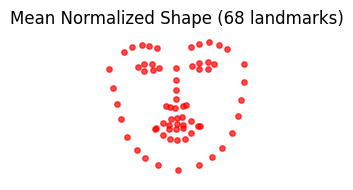

In [44]:
# Cell 5: Build mean normalized shape

# ==================== CONFIGURATION ====================
MIN_LANDMARKS = 5
OUT_MEAN_PATH = Path(DATA_PROCESSED) / "aligned" / "mean_norm_shape.npy"
OUT_MEAN_PATH.parent.mkdir(parents=True, exist_ok=True)

# ==================== HELPER FUNCTIONS ====================
def bbox_diag(pts):
    """Calculate diagonal length of bounding box for scaling."""
    xs, ys = pts[:, 0], pts[:, 1]
    return np.linalg.norm([xs.max() - xs.min(), ys.max() - ys.min()])

def normalize_shape(pts):
    """Center and scale landmarks to unit size."""
    centroid = pts.mean(axis=0)
    scale = bbox_diag(pts)
    if scale < 1e-6:
        scale = 1.0
    return (pts - centroid) / scale

def build_mean_normalized_shape(landmark_root=DATA_LANDMARKS):
    """Build mean shape from all landmark files."""
    all_norms = []
    counts = {}
    
    print(f"Scanning {landmark_root} for landmarks...")
    
    # Collect all landmark files
    for lm_path in landmark_root.rglob("*.npy"):
        # Skip shape files and non-photo files
        if "_shape" in lm_path.stem:
            continue
        if not lm_path.stem.lower().startswith('p'):
            continue
        
        try:
            pts = np.load(str(lm_path))
            
            # Validate
            if pts is None or pts.size == 0 or pts.shape[0] < MIN_LANDMARKS:
                continue
            if pts.ndim != 2 or pts.shape[1] != 2:
                continue
            
            all_norms.append(normalize_shape(pts))
            counts[pts.shape[0]] = counts.get(pts.shape[0], 0) + 1
            
        except Exception as e:
            continue
    
    if len(all_norms) == 0:
        raise RuntimeError("No valid landmarks found! Check your folder path or 'p' prefix filter.")
    
    # Use most common landmark count
    common_n = max(counts, key=counts.get)
    final_norms = [n for n in all_norms if n.shape[0] == common_n]
    
    print(f"Found {len(all_norms)} files. Using {len(final_norms)} shapes with {common_n} points.")
    
    # Compute mean shape
    mean_norm_shape = np.mean(np.stack(final_norms, axis=0), axis=0)
    np.save(OUT_MEAN_PATH, mean_norm_shape)
    print(f"✓ Saved mean normalized shape to: {OUT_MEAN_PATH}")
    
    return mean_norm_shape

# ==================== MAIN EXECUTION ====================
mean_norm = build_mean_normalized_shape()

# ==================== VISUALIZATION ====================
plt.figure(figsize=(2, 2))
plt.scatter(mean_norm[:, 0], -mean_norm[:, 1], s=15, c='red', alpha=0.7)
plt.axis('equal')
plt.axis('off')
plt.title(f"Mean Normalized Shape ({len(mean_norm)} landmarks)")
plt.tight_layout()
plt.show()

# Build Canonical Target Shape + Similarity Transform Helper

In [54]:
# Cell 6: Build canonical target_pts and transform helper


OUTPUT_SIZE = (256,256)
TARGET_FACE_SCALE = 0.55
MEAN_NORM_PATH = Path(DATA_PROCESSED) / "aligned" / "mean_norm_shape.npy"
TARGET_PTS_PATH = Path(DATA_PROCESSED) / "aligned" / "target_pts.npy"
TARGET_PTS_PATH.parent.mkdir(parents=True, exist_ok=True)

if MEAN_NORM_PATH.exists():
    mean_norm = np.load(str(MEAN_NORM_PATH))
else:
    try:
        mean_norm
    except NameError:
        raise RuntimeError("Mean normalized shape not found. Run Cell 5 first.")
    else:
        mean_norm = np.asarray(mean_norm)

w_out, h_out = OUTPUT_SIZE
center_out = np.array([w_out/2.0, h_out/2.0], dtype=np.float32)
target_scale = min(w_out, h_out) * TARGET_FACE_SCALE
target_pts = (mean_norm * target_scale + center_out).astype(np.float32)
np.save(str(TARGET_PTS_PATH), target_pts)
print("Saved target_pts:", TARGET_PTS_PATH)

def estimate_similarity_transform(src_pts, dst_pts, method='ransac'):
    src = np.asarray(src_pts, dtype=np.float32)
    dst = np.asarray(dst_pts, dtype=np.float32)
    if src.shape[0] < 3:
        raise ValueError("At least 3 points required")
    if method == 'ransac':
        M, inliers = cv2.estimateAffinePartial2D(src, dst, method=cv2.RANSAC,
                                                 ransacReprojThreshold=3.0, maxIters=2000)
        if M is None:
            M, inliers = cv2.estimateAffinePartial2D(src, dst, method=cv2.LMEDS)
    else:
        M, inliers = cv2.estimateAffinePartial2D(src, dst, method=cv2.LMEDS)
    if M is None:
        raise RuntimeError("estimateAffinePartial2D failed")
    return M

Saved target_pts: D:\Projects 2025\Caricature Generation\data\processed\aligned\target_pts.npy


# Batch Alignment: Warp All Images Into Canonical Space

In [55]:
# Cell 7: Robust batch alignment with hair-aware cropping

# ==================== CONFIGURATION ====================
OUTPUT_SIZE = (256, 256)
w_out, h_out = OUTPUT_SIZE
DEMO_LIMIT = None
VERBOSE = False  # Set to True to see processing details
BG_FILL = (30, 30, 30)

# Alignment settings
ALIGNMENT_METHOD = 'affine'     # 'similarity' or 'affine'
CROP_STRATEGY = 'adaptive'      # 'tight', 'adaptive', or 'loose'
FACE_SCALE = 0.45              # Face size relative to output (smaller = more room for hair)

# ==================== PATHS ====================
RAWROOT = Path(DATA_RAW)
LANDROOT = Path(DATA_LANDMARKS)
ALIGNED_ROOT = Path(DATA_ALIGNED)
ALIGNED_ROOT.mkdir(parents=True, exist_ok=True)

# ==================== HELPER FUNCTIONS ====================
def transform_landmarks(pts, M):
    """Apply 2x3 affine matrix to landmarks."""
    pts = np.asarray(pts, dtype=np.float32)
    ones = np.ones((pts.shape[0], 1), dtype=np.float32)
    homog = np.concatenate([pts, ones], axis=1)
    return homog @ M.T

def collect_photo_files(root_dir, limit=None):
    """Collect image files with filenames starting with 'p'."""
    files = []
    for img_path in root_dir.rglob('*'):
        if not img_path.suffix.lower() in {'.jpg', '.jpeg', '.png', '.bmp'}:
            continue
        if not img_path.stem.lower().startswith('p'):
            continue
        files.append(img_path)
        if limit and len(files) >= limit:
            break
    return files

def get_face_bbox_with_hair(pts, strategy='adaptive'):
    """
    Calculate face bounding box WITH HAIR included.
    Uses anatomical proportions to estimate head top.
    
    Args:
        pts: Landmarks (N, 2) - assumes 68-point format
        strategy: 'tight', 'adaptive', or 'loose'
    
    Returns:
        bbox: [x_min, y_min, x_max, y_max]
    """
    # Basic landmark bounds
    x_min, y_min = pts.min(axis=0)
    x_max, y_max = pts.max(axis=0)
    
    width = x_max - x_min
    height = y_max - y_min
    
    # Anatomical estimation for hair region
    # For 68-point landmarks: 17-26 are eyebrows, 8 is chin
    if len(pts) >= 27:
        eyebrow_top = pts[17:27, 1].min()  # Top of eyebrows
        jaw_bottom = pts[8, 1] if len(pts) > 8 else y_max  # Chin point
        face_height = jaw_bottom - eyebrow_top
        
        # Human proportions:
        # - Forehead (eyebrow to hairline): ~0.35x face height
        # - Hair volume: ~0.4-0.6x face height
        # - Total above eyebrows: ~0.75x face height
        head_top_estimate = eyebrow_top - (face_height * 0.75)
    else:
        # Fallback for non-standard landmark counts
        head_top_estimate = y_min - (height * 0.5)
    
    # Calculate asymmetric padding
    if strategy == 'tight':
        # Minimal padding - just enough for short hair
        pad_top = max(0, y_min - head_top_estimate) + height * 0.1
        pad_bottom = height * 0.1
        pad_x = width * 0.15
        
    elif strategy == 'adaptive':
        # Recommended - handles most hairstyles
        pad_top = max(0, y_min - head_top_estimate) + height * 0.25
        pad_bottom = height * 0.15
        pad_x = width * 0.25
        
    else:  # loose
        # Maximum padding - for very voluminous hair
        pad_top = max(0, y_min - head_top_estimate) + height * 0.45
        pad_bottom = height * 0.2
        pad_x = width * 0.35
    
    return [
        x_min - pad_x,
        y_min - pad_top,      # Lots of space for hair on top
        x_max + pad_x,
        y_max + pad_bottom    # Less space on bottom
    ]

def estimate_transform_robust(src_pts, dst_pts, method='affine'):
    """
    Estimate transform with multiple fallback strategies.
    NEVER returns None - always finds a transform.
    """
    src = np.asarray(src_pts, dtype=np.float32)
    dst = np.asarray(dst_pts, dtype=np.float32)
    
    # Strategy 1: Try with RANSAC
    try:
        if method == 'affine':
            M, _ = cv2.estimateAffine2D(src, dst, method=cv2.RANSAC, 
                                        ransacReprojThreshold=5.0, maxIters=2000)
        else:
            M, _ = cv2.estimateAffinePartial2D(src, dst, method=cv2.RANSAC,
                                               ransacReprojThreshold=5.0, maxIters=2000)
        if M is not None:
            return M
    except:
        pass
    
    # Strategy 2: Try with LMEDS
    try:
        if method == 'affine':
            M, _ = cv2.estimateAffine2D(src, dst, method=cv2.LMEDS)
        else:
            M, _ = cv2.estimateAffinePartial2D(src, dst, method=cv2.LMEDS)
        if M is not None:
            return M
    except:
        pass
    
    # Strategy 3: Similarity transform with LMEDS
    try:
        M, _ = cv2.estimateAffinePartial2D(src, dst, method=cv2.LMEDS)
        if M is not None:
            return M
    except:
        pass
    
    # Strategy 4: Manual similarity based on centroids (ALWAYS works)
    src_center = src.mean(axis=0)
    dst_center = dst.mean(axis=0)
    
    # Calculate scale
    src_scale = np.sqrt(((src - src_center) ** 2).sum() / len(src))
    dst_scale = np.sqrt(((dst - dst_center) ** 2).sum() / len(dst))
    scale = dst_scale / (src_scale + 1e-8)
    
    # Simple scale + translation transform
    M = np.array([
        [scale, 0, dst_center[0] - scale * src_center[0]],
        [0, scale, dst_center[1] - scale * src_center[1]]
    ], dtype=np.float32)
    
    return M

def crop_and_align_face(img, pts, output_size, face_scale=0.45, crop_strategy='adaptive'):
    """
    Crop face region WITH HAIR and align to output size.
    ALWAYS succeeds by adjusting crop if needed.
    
    Returns:
        warped: Aligned image
        M: Transform matrix
        transformed_pts: Transformed landmarks
    """
    h_img, w_img = img.shape[:2]
    w_out, h_out = output_size
    
    # Get face bounding box with hair included
    bbox = get_face_bbox_with_hair(pts, strategy=crop_strategy)
    x_min, y_min, x_max, y_max = bbox
    
    # Ensure bbox is within image bounds
    x_min = max(0, x_min)
    y_min = max(0, y_min)
    x_max = min(w_img, x_max)
    y_max = min(h_img, y_max)
    
    # Crop dimensions
    crop_w = x_max - x_min
    crop_h = y_max - y_min
    
    # If crop is too small, expand it
    if crop_w < 50 or crop_h < 50:
        center_x = (x_min + x_max) / 2
        center_y = (y_min + y_max) / 2
        crop_w = max(crop_w, 100)
        crop_h = max(crop_h, 100)
        x_min = max(0, center_x - crop_w / 2)
        y_min = max(0, center_y - crop_h / 2)
        x_max = min(w_img, center_x + crop_w / 2)
        y_max = min(h_img, center_y + crop_h / 2)
    
    # Crop image and adjust landmarks
    x_min, y_min, x_max, y_max = int(x_min), int(y_min), int(x_max), int(y_max)
    cropped_img = img[y_min:y_max, x_min:x_max]
    cropped_pts = pts - np.array([x_min, y_min])
    
    # Calculate transform to output size
    # We want the FACE (not the full crop) to be at face_scale
    crop_center = np.array([cropped_img.shape[1] / 2, cropped_img.shape[0] / 2])
    target_center = np.array([w_out / 2, h_out / 2])
    
    # Scale based on face landmarks, not full crop
    face_bbox_in_crop = [
        cropped_pts[:, 0].min(),
        cropped_pts[:, 1].min(),
        cropped_pts[:, 0].max(),
        cropped_pts[:, 1].max()
    ]
    face_w = face_bbox_in_crop[2] - face_bbox_in_crop[0]
    face_h = face_bbox_in_crop[3] - face_bbox_in_crop[1]
    
    # Target scale keeps face at desired size (hair will naturally be included)
    target_scale = (min(w_out, h_out) * face_scale) / max(face_w, face_h)
    
    # Create target points
    pts_centered = cropped_pts - crop_center
    target_pts = pts_centered * target_scale + target_center
    
    # Estimate transform from cropped to output
    M = estimate_transform_robust(cropped_pts, target_pts, method=ALIGNMENT_METHOD)
    
    # Warp to output size
    warped = cv2.warpAffine(
        cropped_img, M, (w_out, h_out),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=BG_FILL
    )
    
    # Transform landmarks
    transformed_pts = transform_landmarks(cropped_pts, M)
    
    return warped, M, transformed_pts

# ==================== LOAD TARGET POINTS ====================
target_path = Path(DATA_PROCESSED) / "aligned" / "target_pts.npy"
if target_path.exists():
    dst_pts_full = np.load(str(target_path)).astype(np.float32)
    print(f"✓ Loaded target points: {dst_pts_full.shape[0]} landmarks")
else:
    print("⚠ Target points not found, will use adaptive alignment")
    dst_pts_full = None

# ==================== COLLECT FILES ====================
raw_images = collect_photo_files(RAWROOT, DEMO_LIMIT)
print(f"Found {len(raw_images)} images to align")
print(f"Crop strategy: {CROP_STRATEGY} (includes hair)")
print(f"Face scale: {FACE_SCALE} (smaller = more room for hair)")

# ==================== MAIN PROCESSING ====================
count_ok = 0
count_skipped = 0

for img_path in tqdm(raw_images, desc="Aligning images with hair"):
    if DEMO_LIMIT and count_ok >= DEMO_LIMIT:
        break
    
    # Determine paths
    rel_path = img_path.relative_to(RAWROOT)
    stem = rel_path.stem
    
    lm_src = LANDROOT / rel_path.with_suffix('.npy')
    out_img_path = ALIGNED_ROOT / f"{stem}_aligned.png"
    out_lm_path = ALIGNED_ROOT / f"{stem}_aligned.npy"
    out_M_path = ALIGNED_ROOT / f"{stem}_affine.npy"
    
    # Skip if no landmarks
    if not lm_src.exists():
        if VERBOSE:
            print(f"Skip (no landmarks): {rel_path}")
        continue
    
    # Skip if already processed
    if out_img_path.exists() and out_lm_path.exists() and out_M_path.exists():
        count_skipped += 1
        continue
    
    # Load image and landmarks
    try:
        src_pts = np.load(str(lm_src)).astype(np.float32)
        img = np.array(Image.open(img_path).convert('RGB'))
    except Exception as e:
        if VERBOSE:
            print(f"Load failed: {rel_path} - {e}")
        continue
    
    # Crop and align face WITH HAIR - ALWAYS succeeds
    try:
        warped, M, transformed_pts = crop_and_align_face(
            img, src_pts, (w_out, h_out), 
            face_scale=FACE_SCALE,
            crop_strategy=CROP_STRATEGY
        )
        
        # Save results
        out_img_path.parent.mkdir(parents=True, exist_ok=True)
        Image.fromarray(warped).save(str(out_img_path))
        np.save(str(out_lm_path), transformed_pts.astype(np.float32))
        np.save(str(out_M_path), M.astype(np.float32))
        
        count_ok += 1
        
    except Exception as e:
        if VERBOSE:
            print(f"Unexpected error: {rel_path} - {e}")
        continue

# ==================== SUMMARY ====================
print(f"\n{'='*60}")
print(f"Alignment Complete (Hair-Aware)")
print(f"{'='*60}")
print(f"✓ Aligned:  {count_ok}")
print(f"○ Skipped:  {count_skipped}")
print(f"Strategy:   {CROP_STRATEGY} crop + {ALIGNMENT_METHOD.upper()}")
print(f"Face scale: {FACE_SCALE} (leaves room for hair)")
print(f"Output dir: {ALIGNED_ROOT}")
print(f"{'='*60}")

✓ Loaded target points: 68 landmarks
Found 5974 images to align
Crop strategy: adaptive (includes hair)
Face scale: 0.45 (smaller = more room for hair)


Aligning images with hair: 100%|█████████████████████████████████████████████████| 5974/5974 [00:01<00:00, 5532.16it/s]


Alignment Complete (Hair-Aware)
✓ Aligned:  36
○ Skipped:  14
Strategy:   adaptive crop + AFFINE
Face scale: 0.45 (leaves room for hair)
Output dir: D:\Projects 2025\Caricature Generation\data\processed\aligned


# TPS Core Functions (Kernel, Solver, Grid Evaluation)

In [64]:
# Cell 8: Full-image TPS warp with LOCAL + GLOBAL exaggeration control
import numpy as np
import cv2
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import scipy.linalg

# ==================== PARAMETERS ====================
REG = 1e-3
GRID_STEP = 2
FALLOFF_RADIUS_FACTOR = 1.8
FALLOFF_SHARPNESS = 2.0
DEMO_N = None       # None -> all aligned images; or set to small int for demo
OUT_SUBDIR = "tps_normalized"
DEBUG = False

# NEW: Exaggeration controls
LOCAL_EXAGGERATION = 1.25   # 1.0 = no change, >1.0 = expand features, <1.0 = compress
GLOBAL_EXAGGERATION = 1.60  # 1.0 = no change, >1.0 = expand entire face, <1.0 = compress

# Features to exaggerate locally (indices for 68-point landmarks)
LOCAL_FEATURE_GROUPS = {
    'jaw': list(range(0, 17)),           # jawline
    'left_eyebrow': list(range(17, 22)), # left eyebrow
    'right_eyebrow': list(range(22, 27)), # right eyebrow
    'nose': list(range(27, 36)),         # nose bridge and tip
    'left_eye': list(range(36, 42)),     # left eye
    'right_eye': list(range(42, 48)),    # right eye
    'mouth': list(range(48, 68)),        # mouth outer and inner
}

ALIGNED_ROOT = Path(DATA_ALIGNED)
OUT_ROOT = Path(DATA_PROCESSED) / OUT_SUBDIR 
OUT_ROOT.mkdir(parents=True, exist_ok=True)

# ==================== TPS FUNCTIONS ====================
def _tps_kernel(r):
    out = np.zeros_like(r, dtype=np.float64)
    nz = r > 0
    out[nz] = (r[nz]**2) * np.log(r[nz])
    return out

def solve_tps(ctrl_pts, target_vals, reg=1e-3):
    N = ctrl_pts.shape[0]
    diff = ctrl_pts[:, None, :] - ctrl_pts[None, :, :]
    r = np.sqrt((diff**2).sum(axis=2))
    K = _tps_kernel(r)
    P = np.concatenate([np.ones((N,1)), ctrl_pts], axis=1)
    A = np.zeros((N+3, N+3), dtype=np.float64)
    A[:N, :N] = K + reg * np.eye(N)
    A[:N, N:] = P
    A[N:, :N] = P.T
    rhs = np.zeros((N+3,), dtype=np.float64)
    rhs[:N] = target_vals.astype(np.float64)
    coeffs = scipy.linalg.solve(A, rhs, assume_a='sym')
    w = coeffs[:N]; a = coeffs[N:]
    return w, a

def tps_eval_grid(ctrl_pts, w, a, xs, ys):
    XX, YY = np.meshgrid(xs, ys)
    pts = np.stack([XX.ravel(), YY.ravel()], axis=1)
    diff = pts[:, None, :] - ctrl_pts[None, :, :]
    r = np.sqrt((diff**2).sum(axis=2))
    U = _tps_kernel(r)
    fflat = U.dot(w) + a[0] + a[1]*pts[:,0] + a[2]*pts[:,1]
    return fflat.reshape(len(ys), len(xs))

# ==================== EXAGGERATION FUNCTIONS ====================
def apply_local_exaggeration(pts, local_factor=1.2, feature_groups=None):
    """
    Apply local exaggeration to specific facial features.
    Each feature group is scaled relative to its own center.
    """
    if feature_groups is None or local_factor == 1.0:
        return pts.copy()
    
    pts_exag = pts.copy()
    
    for feature_name, indices in feature_groups.items():
        valid_idx = [i for i in indices if i < len(pts)]
        if len(valid_idx) == 0:
            continue
        
        feature_pts = pts[valid_idx]
        feature_center = feature_pts.mean(axis=0)
        
        for i in valid_idx:
            pts_exag[i] = feature_center + local_factor * (pts[i] - feature_center)
    
    return pts_exag

def apply_global_exaggeration(pts, global_factor=1.0):
    """
    Apply global exaggeration to entire face.
    Scale all points relative to face center.
    """
    if global_factor == 1.0:
        return pts.copy()
    
    center = pts.mean(axis=0)
    pts_exag = center + global_factor * (pts - center)
    return pts_exag

def compute_tps_warp(img, src_pts, dst_pts, grid_step=2):
    """
    Compute TPS warp maps from src_pts to dst_pts.
    Returns the displacement maps (map_x, map_y).
    """
    h, w = img.shape[:2]
    
    # Solve inverse TPS
    w_x, a_x = solve_tps(dst_pts, src_pts[:,0], reg=REG)
    w_y, a_y = solve_tps(dst_pts, src_pts[:,1], reg=REG)
    
    # Evaluate on grid
    if grid_step <= 1:
        xs = np.arange(0, w)
        ys = np.arange(0, h)
        map_x = tps_eval_grid(dst_pts, w_x, a_x, xs, ys)
        map_y = tps_eval_grid(dst_pts, w_y, a_y, xs, ys)
    else:
        xs_c = np.arange(0, w, grid_step)
        ys_c = np.arange(0, h, grid_step)
        map_xc = tps_eval_grid(dst_pts, w_x, a_x, xs_c, ys_c)
        map_yc = tps_eval_grid(dst_pts, w_y, a_y, xs_c, ys_c)
        map_x = cv2.resize(map_xc.astype(np.float32), (w, h), interpolation=cv2.INTER_CUBIC)
        map_y = cv2.resize(map_yc.astype(np.float32), (w, h), interpolation=cv2.INTER_CUBIC)
    
    return map_x, map_y

# ==================== MAIN PROCESSING ====================
aligned_imgs = sorted(list(ALIGNED_ROOT.rglob("*_aligned.png")))
aligned_imgs = [p for p in aligned_imgs if p.stem.lower().startswith('p')]

if len(aligned_imgs) == 0:
    raise RuntimeError("No aligned images found. Run alignment first.")

to_process = aligned_imgs if DEMO_N is None else aligned_imgs[:DEMO_N]

print(f"Processing with LOCAL_EXAGGERATION={LOCAL_EXAGGERATION}, GLOBAL_EXAGGERATION={GLOBAL_EXAGGERATION}")

for p in to_process:
    lm_p = Path(str(p).replace("_aligned.png", "_aligned.npy"))
    if not lm_p.exists():
        print("Skip (no lm):", p)
        continue
    
    out_path = OUT_ROOT / (p.stem.replace("_aligned", "") + "_tps.png")

    try:
        img = np.array(Image.open(p).convert("RGB"))
        h, w = img.shape[:2]
        pts = np.load(str(lm_p)).astype(np.float64)

        # Step 1: Apply local exaggeration
        pts_local = apply_local_exaggeration(pts.copy(), LOCAL_EXAGGERATION, LOCAL_FEATURE_GROUPS)
        
        # Step 2: Apply global exaggeration to locally-exaggerated points
        pts_final = apply_global_exaggeration(pts_local, GLOBAL_EXAGGERATION)

        # Compute TPS warp from original to final
        map_x, map_y = compute_tps_warp(img, pts, pts_final, GRID_STEP)

        # Identity grid
        id_x = np.tile(np.arange(w, dtype=np.float32)[None, :], (h, 1))
        id_y = np.tile(np.arange(h, dtype=np.float32)[:, None], (1, w))

        # Gaussian falloff
        centroid = pts.mean(axis=0)
        bbox_diag = np.linalg.norm([pts[:,0].max()-pts[:,0].min(), pts[:,1].max()-pts[:,1].min()])
        radius = bbox_diag * FALLOFF_RADIUS_FACTOR if bbox_diag > 1e-6 else max(h,w)*0.25
        xx, yy = np.meshgrid(np.arange(w), np.arange(h))
        dist = np.sqrt((xx - centroid[0])**2 + (yy - centroid[1])**2)
        weight = np.exp(- (dist / (radius + 1e-8))**2 * FALLOFF_SHARPNESS).astype(np.float32)

        # Blend TPS warp with identity
        final_map_x = (1.0 - weight) * id_x + weight * map_x.astype(np.float32)
        final_map_y = (1.0 - weight) * id_y + weight * map_y.astype(np.float32)

        final_map_x = np.clip(final_map_x, 0.0, float(w-1)).astype(np.float32)
        final_map_y = np.clip(final_map_y, 0.0, float(h-1)).astype(np.float32)

        # Apply warp
        src_u8 = np.clip(img, 0, 255).astype(np.uint8)
        warped = cv2.remap(src_u8, final_map_x, final_map_y, 
                          interpolation=cv2.INTER_CUBIC,
                          borderMode=cv2.BORDER_CONSTANT, 
                          borderValue=(0,0,0))

        out_path.parent.mkdir(parents=True, exist_ok=True)
        Image.fromarray(warped).save(str(out_path))

        if DEBUG:
            fig, ax = plt.subplots(1, 4, figsize=(16, 4))
            
            ax[0].imshow(img)
            ax[0].set_title("Original")
            ax[0].scatter(pts[:,0], pts[:,1], c='red', s=10, alpha=0.5)
            ax[0].axis('off')
            
            ax[1].imshow(img)
            ax[1].set_title(f"Local Exag: {LOCAL_EXAGGERATION}")
            ax[1].scatter(pts_local[:,0], pts_local[:,1], c='blue', s=10, alpha=0.5)
            ax[1].axis('off')
            
            ax[2].imshow(warped)
            ax[2].set_title(f"Final (Global: {GLOBAL_EXAGGERATION})")
            ax[2].scatter(pts_final[:,0], pts_final[:,1], c='green', s=10, alpha=0.5)
            ax[2].axis('off')
            
            ax[3].imshow(weight, cmap='inferno')
            ax[3].set_title("Falloff Weight")
            ax[3].axis('off')
            
            plt.tight_layout()
            plt.show()

    except Exception as e:
        print("Failed:", p, e)
        continue

print(f"\n✓ TPS outputs saved to: {OUT_ROOT}")

Processing with LOCAL_EXAGGERATION=1.25, GLOBAL_EXAGGERATION=1.6

✓ TPS outputs saved to: D:\Projects 2025\Caricature Generation\data\processed\tps_normalized


# Visualization for one warped example

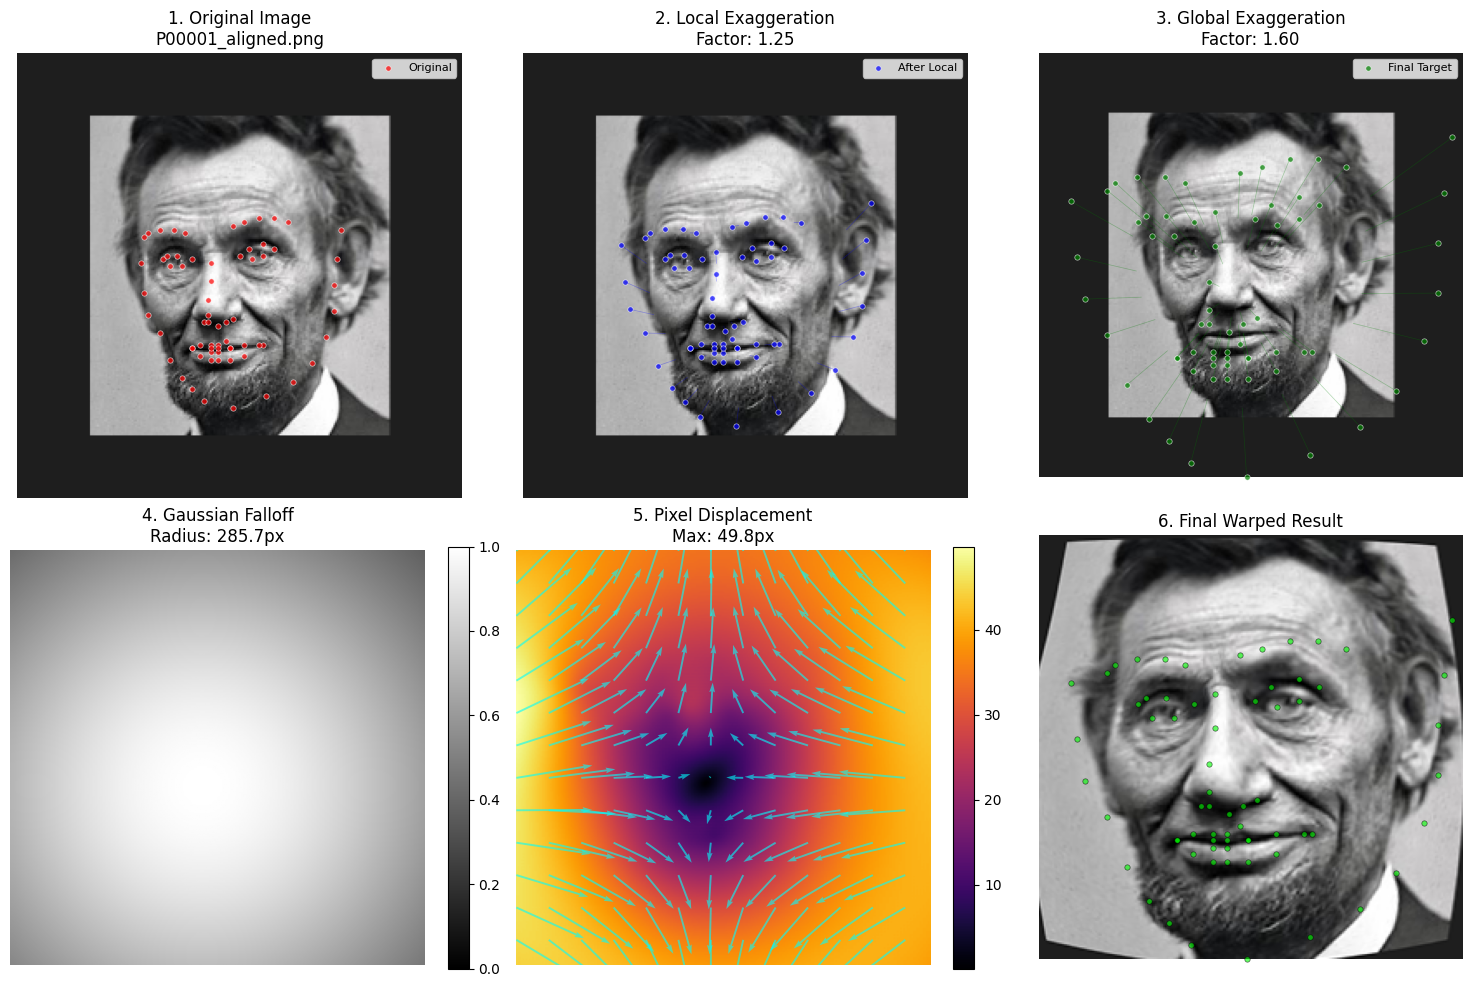


IMAGE: P00001_aligned.png
Exaggeration Settings:
  • Local Factor:  1.250
  • Global Factor: 1.600

Landmark Movement:
  • Original → Local:  avg=4.98px, max=20.82px
  • Local → Global:    avg=25.54px, max=60.67px
  • Original → Final:  avg=29.63px, max=81.20px

Warp Statistics:
  • Falloff Radius: 285.7px
  • Max Displacement: 49.78px
  • Mean Displacement: 32.50px
  • Pixels Affected (>1px): 65523 (100.0%)


In [65]:
# === CELL 10: Visualization & Debug (Local + Global Exaggeration Check) ===
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
import cv2

# ---- User Controls ----
SAMPLE_INDEX = 0          # Change this to view different images (0, 1, 2...)
SHOW_ARROWS = True        # Show vector arrows for movement
SHOW_LANDMARKS = True     # Show landmark transformations
GRID_STEP = 2             # Resolution of the warp grid (for display)

# ---- Visualization Mode ----
# 'full' - Show all 6 panels (original, local, global, weight, distortion, final)
# 'compact' - Show 4 panels (original w/landmarks, weight, distortion, final)
VIZ_MODE = 'full'

# Paths
ALIGNED_ROOT = Path(DATA_ALIGNED)
OUT_ROOT = Path(DATA_PROCESSED) / "tps_normalized"

# 1. Load Data
aligned_imgs = sorted(list(ALIGNED_ROOT.rglob("*_aligned.png")))
aligned_imgs = [p for p in aligned_imgs if p.stem.lower().startswith('p')]

if len(aligned_imgs) == 0:
    raise RuntimeError("No images found. Run alignment first.")

# Clamp index
SAMPLE_INDEX = max(0, min(SAMPLE_INDEX, len(aligned_imgs)-1))
img_path = aligned_imgs[SAMPLE_INDEX]
lm_path = Path(str(img_path).replace("_aligned.png", "_aligned.npy"))

if not lm_path.exists():
    raise RuntimeError(f"Missing landmarks for {img_path.name}")

# Load Images & Points
img = np.array(Image.open(img_path).convert("RGB"))
h, w = img.shape[:2]
src_pts = np.load(str(lm_path)).astype(np.float64)

# Load output if exists
out_path = OUT_ROOT / (img_path.stem + "_tps.png")
if out_path.exists():
    warped = np.array(Image.open(out_path).convert("RGB"))
else:
    print(f"Warning: Output not found at {out_path}, will recompute warp")
    warped = None

# 2. Re-Compute Exaggerated Landmarks (Same as Cell 8)
# Apply local exaggeration
pts_local = apply_local_exaggeration(
    src_pts.copy(), 
    local_factor=LOCAL_EXAGGERATION,
    feature_groups=LOCAL_FEATURE_GROUPS
)

# Apply global exaggeration
dst_pts = apply_global_exaggeration(
    pts_local, 
    global_factor=GLOBAL_EXAGGERATION
)

# 3. Re-Compute TPS if needed
if warped is None:
    # Calculate TPS coefficients
    w_x, a_x = solve_tps(dst_pts, src_pts[:,0], reg=REG)
    w_y, a_y = solve_tps(dst_pts, src_pts[:,1], reg=REG)
    
    # Evaluate Grid
    xs_c = np.arange(0, w, GRID_STEP)
    ys_c = np.arange(0, h, GRID_STEP)
    map_xc = tps_eval_grid(dst_pts, w_x, a_x, xs_c, ys_c)
    map_yc = tps_eval_grid(dst_pts, w_y, a_y, xs_c, ys_c)
    map_x = cv2.resize(map_xc.astype(np.float32), (w, h), interpolation=cv2.INTER_CUBIC)
    map_y = cv2.resize(map_yc.astype(np.float32), (w, h), interpolation=cv2.INTER_CUBIC)
    
    # Calculate Gaussian Falloff
    centroid = src_pts.mean(axis=0)
    bbox_diag = np.linalg.norm([src_pts[:,0].max()-src_pts[:,0].min(), 
                                 src_pts[:,1].max()-src_pts[:,1].min()])
    radius = bbox_diag * FALLOFF_RADIUS_FACTOR if bbox_diag > 1e-6 else max(h,w)*0.25
    xx, yy = np.meshgrid(np.arange(w), np.arange(h))
    dist = np.sqrt((xx - centroid[0])**2 + (yy - centroid[1])**2)
    weight = np.exp(- (dist / (radius + 1e-8))**2 * FALLOFF_SHARPNESS).astype(np.float32)
    
    # Blend Maps
    id_x = np.tile(np.arange(w, dtype=np.float32)[None, :], (h, 1))
    id_y = np.tile(np.arange(h, dtype=np.float32)[:, None], (1, w))
    final_map_x = (1.0 - weight) * id_x + weight * map_x
    final_map_y = (1.0 - weight) * id_y + weight * map_y
    
    # Warp
    src_u8 = np.clip(img, 0, 255).astype(np.uint8)
    warped = cv2.remap(src_u8, final_map_x, final_map_y, 
                       interpolation=cv2.INTER_CUBIC,
                       borderMode=cv2.BORDER_CONSTANT, 
                       borderValue=(0,0,0))
else:
    # Still need to compute these for visualization
    centroid = src_pts.mean(axis=0)
    bbox_diag = np.linalg.norm([src_pts[:,0].max()-src_pts[:,0].min(), 
                                 src_pts[:,1].max()-src_pts[:,1].min()])
    radius = bbox_diag * FALLOFF_RADIUS_FACTOR if bbox_diag > 1e-6 else max(h,w)*0.25
    xx, yy = np.meshgrid(np.arange(w), np.arange(h))
    dist = np.sqrt((xx - centroid[0])**2 + (yy - centroid[1])**2)
    weight = np.exp(- (dist / (radius + 1e-8))**2 * FALLOFF_SHARPNESS).astype(np.float32)
    
    # Compute TPS for distortion visualization
    w_x, a_x = solve_tps(dst_pts, src_pts[:,0], reg=REG)
    w_y, a_y = solve_tps(dst_pts, src_pts[:,1], reg=REG)
    xs_c = np.arange(0, w, GRID_STEP)
    ys_c = np.arange(0, h, GRID_STEP)
    map_xc = tps_eval_grid(dst_pts, w_x, a_x, xs_c, ys_c)
    map_yc = tps_eval_grid(dst_pts, w_y, a_y, xs_c, ys_c)
    map_x = cv2.resize(map_xc.astype(np.float32), (w, h), interpolation=cv2.INTER_CUBIC)
    map_y = cv2.resize(map_yc.astype(np.float32), (w, h), interpolation=cv2.INTER_CUBIC)
    id_x = np.tile(np.arange(w, dtype=np.float32)[None, :], (h, 1))
    id_y = np.tile(np.arange(h, dtype=np.float32)[:, None], (1, w))
    final_map_x = (1.0 - weight) * id_x + weight * map_x
    final_map_y = (1.0 - weight) * id_y + weight * map_y

# 4. Calculate Distortion Magnitude (Heatmap)
disp_x = final_map_x - id_x
disp_y = final_map_y - id_y
magnitude = np.sqrt(disp_x**2 + disp_y**2)

# ---- Plotting ----
if VIZ_MODE == 'full':
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    ax = axes.ravel()
    
    # Panel 1: Original + Source Landmarks
    ax[0].imshow(img)
    ax[0].set_title(f"1. Original Image\n{img_path.name}")
    if SHOW_LANDMARKS:
        ax[0].scatter(src_pts[:, 0], src_pts[:, 1], c='red', s=15, 
                     label='Original', alpha=0.7, edgecolors='white', linewidths=0.5)
        ax[0].legend(loc='upper right', fontsize=8)
    ax[0].axis('off')
    
    # Panel 2: Local Exaggeration
    ax[1].imshow(img)
    ax[1].set_title(f"2. Local Exaggeration\nFactor: {LOCAL_EXAGGERATION:.2f}")
    if SHOW_LANDMARKS:
        # Show movement vectors
        for i in range(len(src_pts)):
            ax[1].plot([src_pts[i,0], pts_local[i,0]], 
                      [src_pts[i,1], pts_local[i,1]], 
                      'b-', alpha=0.3, linewidth=0.5)
        ax[1].scatter(pts_local[:, 0], pts_local[:, 1], c='blue', s=15,
                     label='After Local', alpha=0.7, edgecolors='white', linewidths=0.5)
        ax[1].legend(loc='upper right', fontsize=8)
    ax[1].axis('off')
    
    # Panel 3: Global Exaggeration
    ax[2].imshow(img)
    ax[2].set_title(f"3. Global Exaggeration\nFactor: {GLOBAL_EXAGGERATION:.2f}")
    if SHOW_LANDMARKS:
        # Show movement from local to global
        for i in range(len(pts_local)):
            ax[2].plot([pts_local[i,0], dst_pts[i,0]], 
                      [pts_local[i,1], dst_pts[i,1]], 
                      'g-', alpha=0.3, linewidth=0.5)
        ax[2].scatter(dst_pts[:, 0], dst_pts[:, 1], c='green', s=15,
                     label='Final Target', alpha=0.7, edgecolors='white', linewidths=0.5)
        ax[2].legend(loc='upper right', fontsize=8)
    ax[2].axis('off')
    
    # Panel 4: Weight Mask
    im4 = ax[3].imshow(weight, cmap='gray', vmin=0, vmax=1)
    ax[3].set_title(f"4. Gaussian Falloff\nRadius: {radius:.1f}px")
    ax[3].axis('off')
    plt.colorbar(im4, ax=ax[3], fraction=0.046)
    
    # Panel 5: Distortion Heatmap
    im5 = ax[4].imshow(magnitude, cmap='inferno')
    ax[4].set_title(f"5. Pixel Displacement\nMax: {magnitude.max():.1f}px")
    if SHOW_ARROWS:
        # Plot subsampled vector field
        step = 20
        q_x = xx[::step, ::step]
        q_y = yy[::step, ::step]
        q_u = disp_x[::step, ::step]
        q_v = disp_y[::step, ::step]
        ax[4].quiver(q_x, q_y, q_u, q_v, color='cyan', alpha=0.6, scale=1, scale_units='xy')
    ax[4].axis('off')
    plt.colorbar(im5, ax=ax[4], fraction=0.046)
    
    # Panel 6: Final Result
    ax[5].imshow(warped)
    ax[5].set_title("6. Final Warped Result")
    if SHOW_LANDMARKS:
        ax[5].scatter(dst_pts[:, 0], dst_pts[:, 1], c='lime', s=15,
                     alpha=0.6, edgecolors='black', linewidths=0.5)
    ax[5].axis('off')
    
else:  # compact mode
    fig, axes = plt.subplots(2, 2, figsize=(12, 12))
    ax = axes.ravel()
    
    # Panel 1: Source + All Landmarks
    ax[0].imshow(img)
    ax[0].set_title(f"Original + Landmark Transformations\n{img_path.name}")
    if SHOW_LANDMARKS:
        ax[0].scatter(src_pts[:, 0], src_pts[:, 1], c='red', s=20, 
                     label=f'Original', alpha=0.8, marker='o')
        ax[0].scatter(pts_local[:, 0], pts_local[:, 1], c='blue', s=15,
                     label=f'Local ({LOCAL_EXAGGERATION:.2f})', alpha=0.6, marker='s')
        ax[0].scatter(dst_pts[:, 0], dst_pts[:, 1], c='green', s=15,
                     label=f'Global ({GLOBAL_EXAGGERATION:.2f})', alpha=0.6, marker='^')
        # Draw transformation lines
        for i in range(len(src_pts)):
            ax[0].plot([src_pts[i,0], dst_pts[i,0]], 
                      [src_pts[i,1], dst_pts[i,1]], 
                      'yellow', alpha=0.2, linewidth=0.5)
        ax[0].legend(loc='upper right', fontsize=9)
    ax[0].axis('off')
    
    # Panel 2: Weight Mask
    im2 = ax[1].imshow(weight, cmap='gray', vmin=0, vmax=1)
    ax[1].set_title(f"Gaussian Falloff Mask\n(Radius: {radius:.1f}px, White = Full Warp)")
    ax[1].axis('off')
    plt.colorbar(im2, ax=ax[1], fraction=0.046)
    
    # Panel 3: Distortion Heatmap
    im3 = ax[2].imshow(magnitude, cmap='inferno')
    ax[2].set_title(f"Pixel Displacement Magnitude\n(Max: {magnitude.max():.1f}px)")
    if SHOW_ARROWS:
        step = 16
        q_x = xx[::step, ::step]
        q_y = yy[::step, ::step]
        q_u = disp_x[::step, ::step]
        q_v = disp_y[::step, ::step]
        ax[2].quiver(q_x, q_y, q_u, q_v, color='cyan', alpha=0.5, scale=1, scale_units='xy')
    ax[2].axis('off')
    plt.colorbar(im3, ax=ax[2], fraction=0.046)
    
    # Panel 4: Final Result
    ax[3].imshow(warped)
    ax[3].set_title("Final Normalized Output")
    ax[3].axis('off')

plt.tight_layout()
plt.show()

# Print Statistics
print("\n" + "="*60)
print(f"IMAGE: {img_path.name}")
print("="*60)
print(f"Exaggeration Settings:")
print(f"  • Local Factor:  {LOCAL_EXAGGERATION:.3f}")
print(f"  • Global Factor: {GLOBAL_EXAGGERATION:.3f}")
print(f"\nLandmark Movement:")
print(f"  • Original → Local:  avg={np.linalg.norm(pts_local - src_pts, axis=1).mean():.2f}px, "
      f"max={np.linalg.norm(pts_local - src_pts, axis=1).max():.2f}px")
print(f"  • Local → Global:    avg={np.linalg.norm(dst_pts - pts_local, axis=1).mean():.2f}px, "
      f"max={np.linalg.norm(dst_pts - pts_local, axis=1).max():.2f}px")
print(f"  • Original → Final:  avg={np.linalg.norm(dst_pts - src_pts, axis=1).mean():.2f}px, "
      f"max={np.linalg.norm(dst_pts - src_pts, axis=1).max():.2f}px")
print(f"\nWarp Statistics:")
print(f"  • Falloff Radius: {radius:.1f}px")
print(f"  • Max Displacement: {magnitude.max():.2f}px")
print(f"  • Mean Displacement: {magnitude.mean():.2f}px")
print(f"  • Pixels Affected (>1px): {(magnitude > 1.0).sum()} ({100*(magnitude > 1.0).sum()/(h*w):.1f}%)")
print("="*60)